# Run MOFA analysis in CD4 Naive cells of preRA Teaseq

- related to Fig5 and Fig S11
- CD4 naive cells ARI vs CON2
- remove subject BR2024 from the analysis (This control subject had a positive CCP result at another visit hence removing from the analysis)

1. load preprocessed clinical lab, olink, scRNA, scATAC data
   - extract the sample pseudobulk level data
   - for atac-seq data, TF activivies infered from chromVAR is used
2. run MOFA
3. examine MOFA factor 1


# set up


In [108]:
# import libraries
quiet_library <- function(...) {
  suppressPackageStartupMessages(library(...))
}
quiet_library("tidyverse")
quiet_library("Matrix")
quiet_library("viridis")
quiet_library("MOFA2")
quiet_library("data.table")
quiet_library("jsonlite")
quiet_library("parallel")
quiet_library("ggpubr")
quiet_library("ComplexHeatmap")
quiet_library("hise")

In [2]:
# define file path
fig_path <- "/home/workspace/private/teaseq-analysis-v2-ide/preRA_teaseq/figures"
data_path <- "/home/workspace/private/teaseq-analysis-v2-ide/preRA_teaseq/EXP-00243"
meta_path <- "/home/workspace/private/teaseq-analysis-v2-ide/preRA_teaseq/meta_data"
output_path <- "/home/workspace/private/teaseq-analysis-v2-ide/preRA_teaseq/output_results/MOFA"
if (!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if (!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))
# define a project name
proj_name <- "PreRA_teaseq_MOFA_cd4na"

In [3]:
# define the color palette to be used
npg_color <- c(
  "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
  "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
  "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)
con_ari_colors <- c("#5AAA46", "#F59F00")
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 20, repr.plot.height = 15)

# Load and prepare Data


In [15]:
# load metadata in
meta_data <- read_csv(file.path(meta_path, "PreRA_teaseq_metadata.csv"))
meta_data <- meta_data %>%
  dplyr::select(all_of(c(
    "subject.subjectGuid", "sample.sampleKitGuid",
    "subject.biologicalSex", "cohort.cohortGuid", "age",
    "rheumatoid_factor_iga", "rheumatoid_factor_igm",
    "anti_ccp3"
  ))) %>%
  dplyr::rename("sample" = "subject.subjectGuid") %>%
  mutate(cohort = if_else(cohort.cohortGuid == "CU1", "at_risk", "healthy"))
meta_data %>% head()

Rows: 13 Columns: 130
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (26): sample.id, sample.sampleKitGuid, sample.visitName, sample.visitDe...
dbl  (70): sample.daysSinceFirstVisit, file.majorVersion, subject.birthYear,...
lgl  (32): sample.bridgingControl, file.panel, file.pool, file.userTags.deta...
dttm  (2): lastUpdated, sample.drawDate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


sample,sample.sampleKitGuid,subject.biologicalSex,cohort.cohortGuid,age,rheumatoid_factor_iga,rheumatoid_factor_igm,anti_ccp3,cohort
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
CU1005,KT00060,Female,CU1,40,0.25,0.25,195,at_risk
CU1013,KT00065,Female,CU1,61,NA,NA,262,at_risk
CU1019,KT00067,Female,CU1,74,0.25,0.25,30,at_risk
CU1022,KT00073,Female,CU1,71,11.41,3.09,64,at_risk
CU1002,KT00096,Female,CU1,79,0.25,4.03,22,at_risk
CU1004,KT00212,Female,CU1,33,0.25,1.38,28,at_risk


In [139]:
# add metadata to the model
meta_data <- meta_data %>%
  filter(sample != "BR2024") %>%
  mutate(status = factor(recode(cohort, "at_risk" = "ARI", "healthy" = "CON2"),
    levels = c("CON2", "ARI")
  ))
meta_data

sample,sample.sampleKitGuid,subject.biologicalSex,cohort.cohortGuid,age,rheumatoid_factor_iga,rheumatoid_factor_igm,anti_ccp3,cohort,status
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<fct>
CU1005,KT00060,Female,CU1,40,0.25,0.25,195,at_risk,ARI
CU1013,KT00065,Female,CU1,61,NA,NA,262,at_risk,ARI
CU1019,KT00067,Female,CU1,74,0.25,0.25,30,at_risk,ARI
CU1022,KT00073,Female,CU1,71,11.41,3.09,64,at_risk,ARI
CU1002,KT00096,Female,CU1,79,0.25,4.03,22,at_risk,ARI
CU1004,KT00212,Female,CU1,33,0.25,1.38,28,at_risk,ARI
CU1009,KT00219,Female,CU1,57,0.25,26.85,91,at_risk,ARI
BR1019,KT00331,Female,BR1,35,NA,NA,NA,healthy,CON2
BR1031,KT00332,Female,BR1,33,NA,NA,NA,healthy,CON2


## Psudobulk approach


### load psudobulk rna, adt, peaks,


In [6]:
# load rna psudobulk data
# gene expression matrix is summarized at the sample level and vst transformed
cd4na_rna_psudo <- readRDS(file.path(data_path, "PreRA_teaseq_cd4na_t_rna_subject_PseudoBulk.rds"))

In [7]:
cd4na_rna_psudo

Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count



Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQR

class: SingleCellExperiment 
dim: 4089 12 
metadata(0):
assays(2): counts normalized_counts
rownames(4089): CCNL2 MRPL20 ... MT-CYB AL592183.1
rowData names(0):
colnames: NULL
colData names(99): nCount_ADT nFeature_ADT ... cd4t_annotation.1 ncells
reducedDimNames(10): PCA REF.SPCA ... ADT_UMAP APCA
mainExpName: RNA
altExpNames(0):

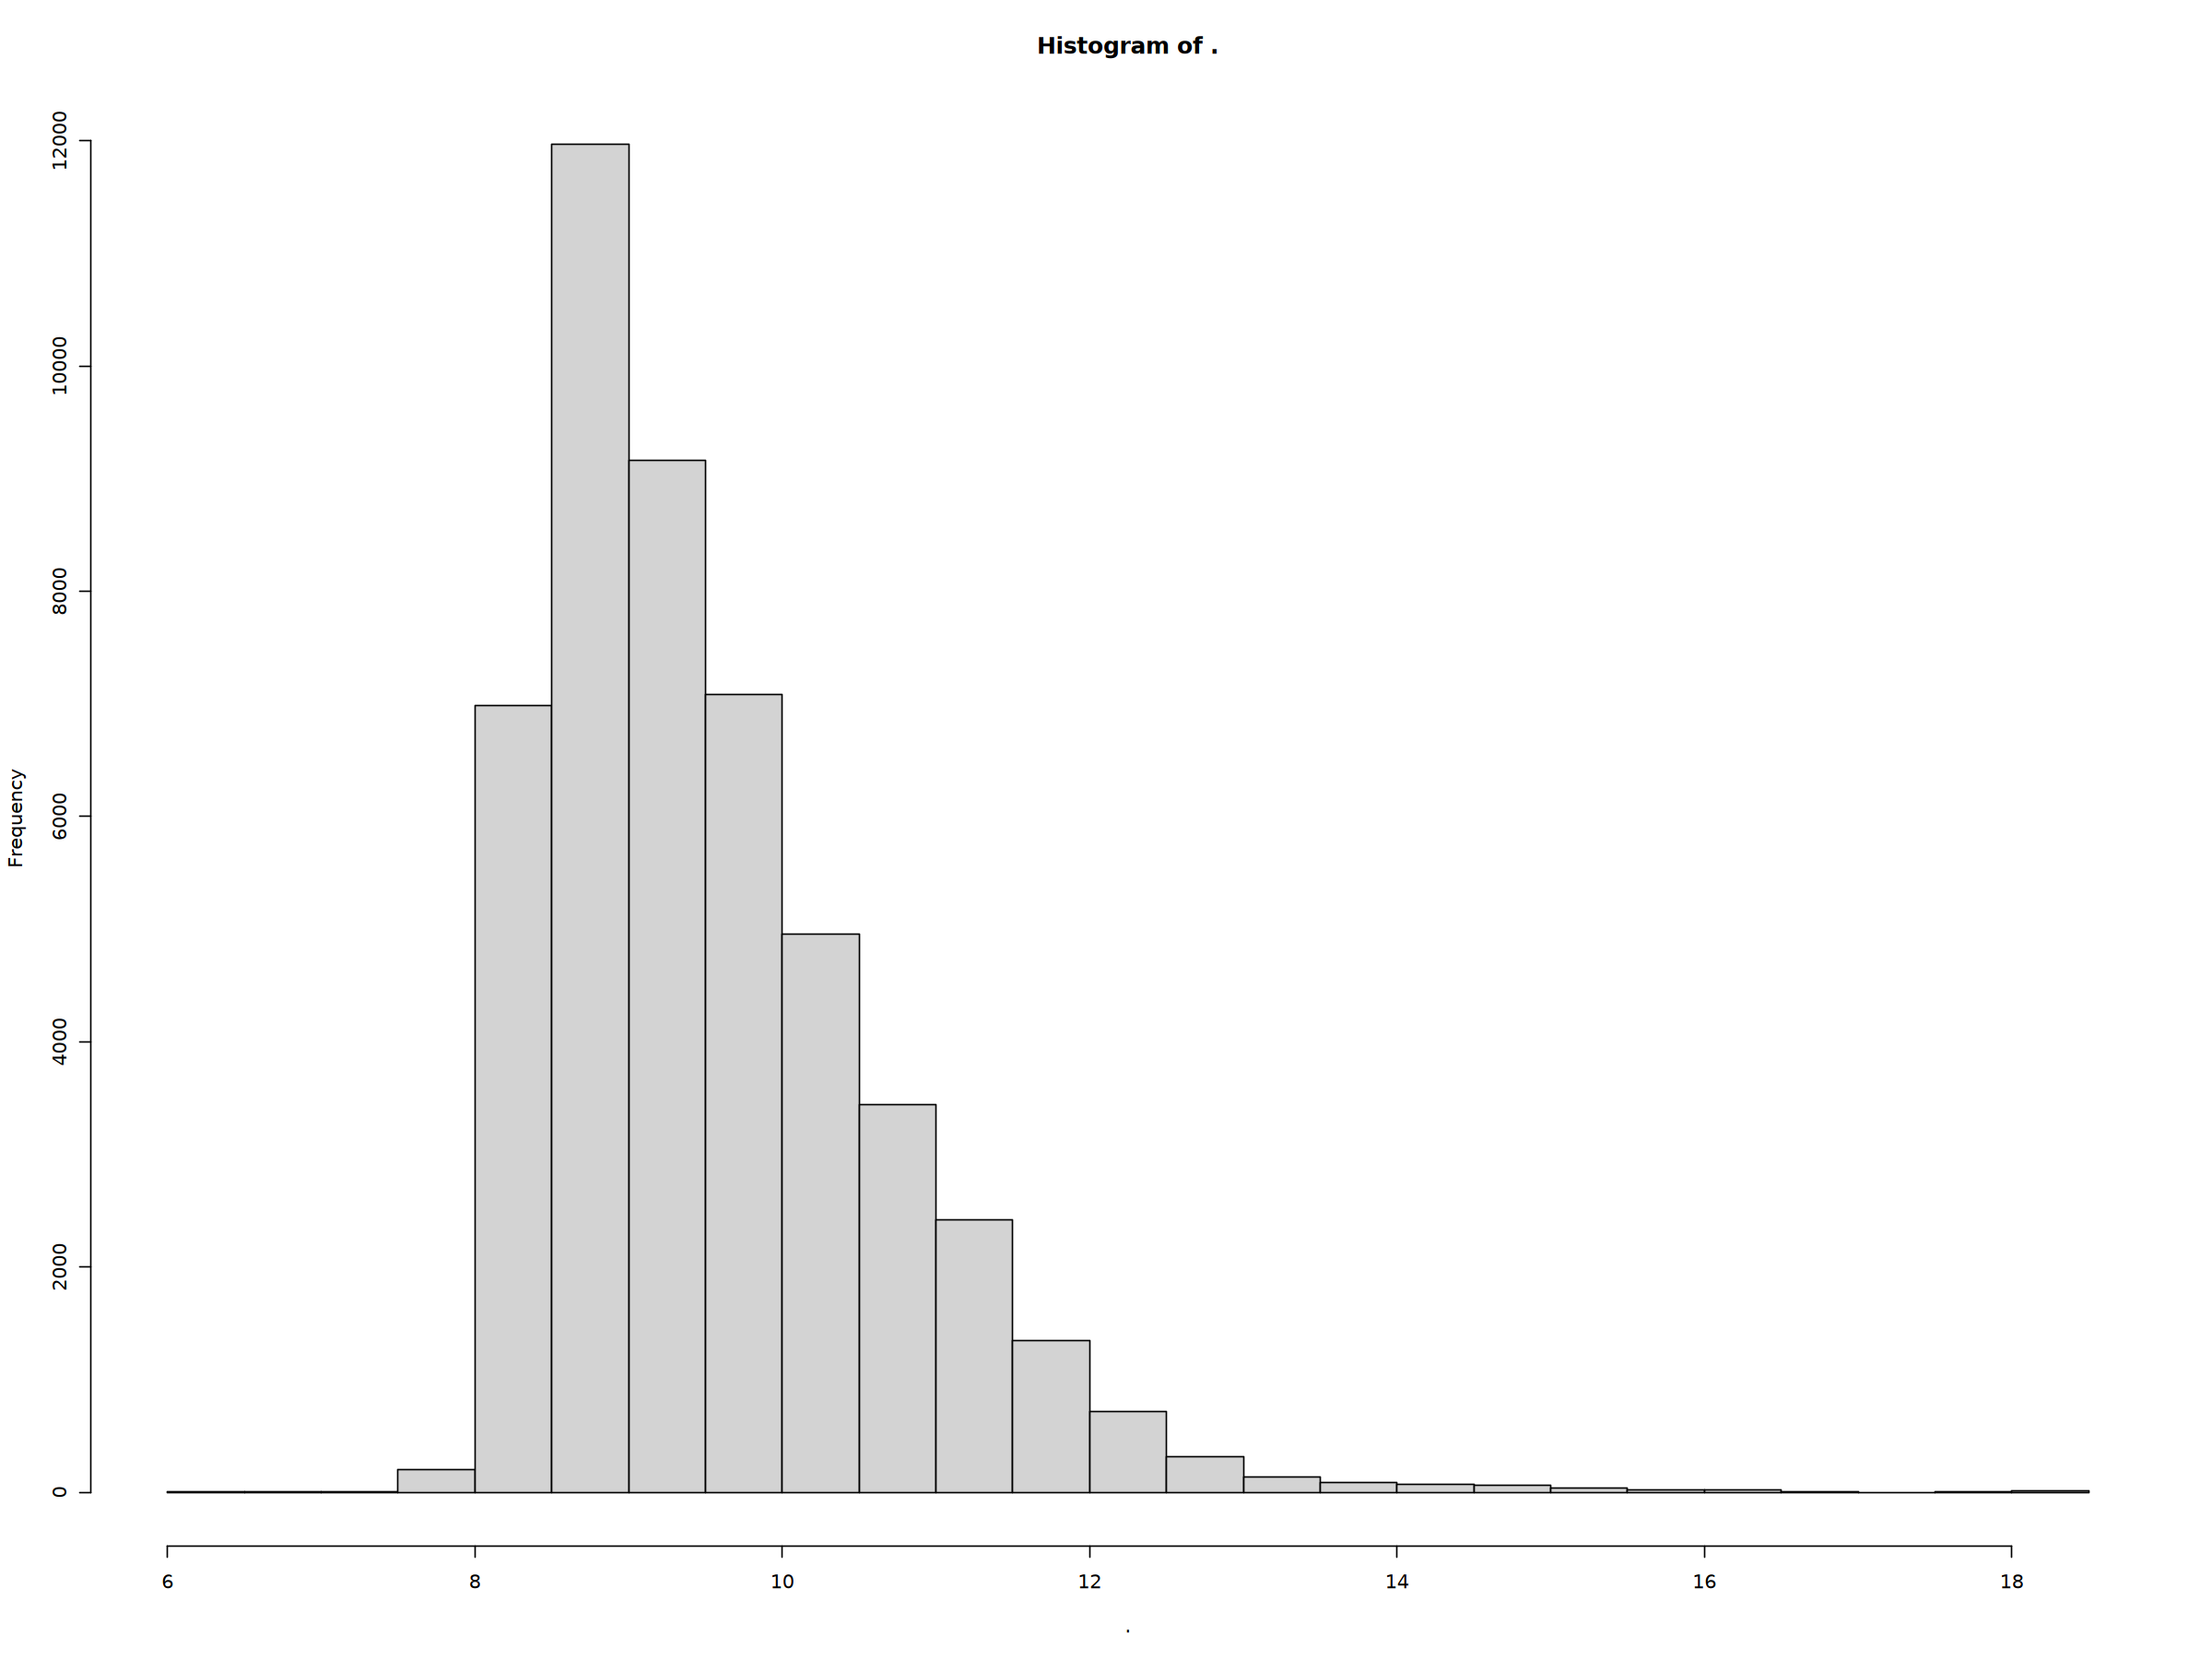

In [8]:
# check the distribution of the gene expression data
assay(cd4na_rna_psudo, "normalized_counts") %>% hist()

In [9]:
# extract the rna data into the long table formate and scale the data per MOFA requirement.
norm_rna_counts <- assay(cd4na_rna_psudo, "normalized_counts")
colnames(norm_rna_counts) <- cd4na_rna_psudo$subject_id
norm_rna_counts_long <- norm_rna_counts %>%
  as_tibble(rownames = "gene") %>%
  pivot_longer(cols = -gene, names_to = "subject_id", values_to = "value") %>%
  mutate(view = "rna", feature = paste("rna", gene, sep = "_")) %>%
  group_by(feature) %>%
  mutate(value = scale(value)) %>%
  ungroup()
norm_rna_counts_long %>% head()

gene,subject_id,value,view,feature
<chr>,<chr>,"<dbl[,1]>",<chr>,<chr>
CCNL2,BR1019,0.1396079,rna,rna_CCNL2
CCNL2,BR1031,0.4630008,rna,rna_CCNL2
CCNL2,BR2018,0.2853191,rna,rna_CCNL2
CCNL2,BR2029,-2.1981312,rna,rna_CCNL2
CCNL2,BR2034,0.9791970,rna,rna_CCNL2
CCNL2,CU1002,-1.2806773,rna,rna_CCNL2


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


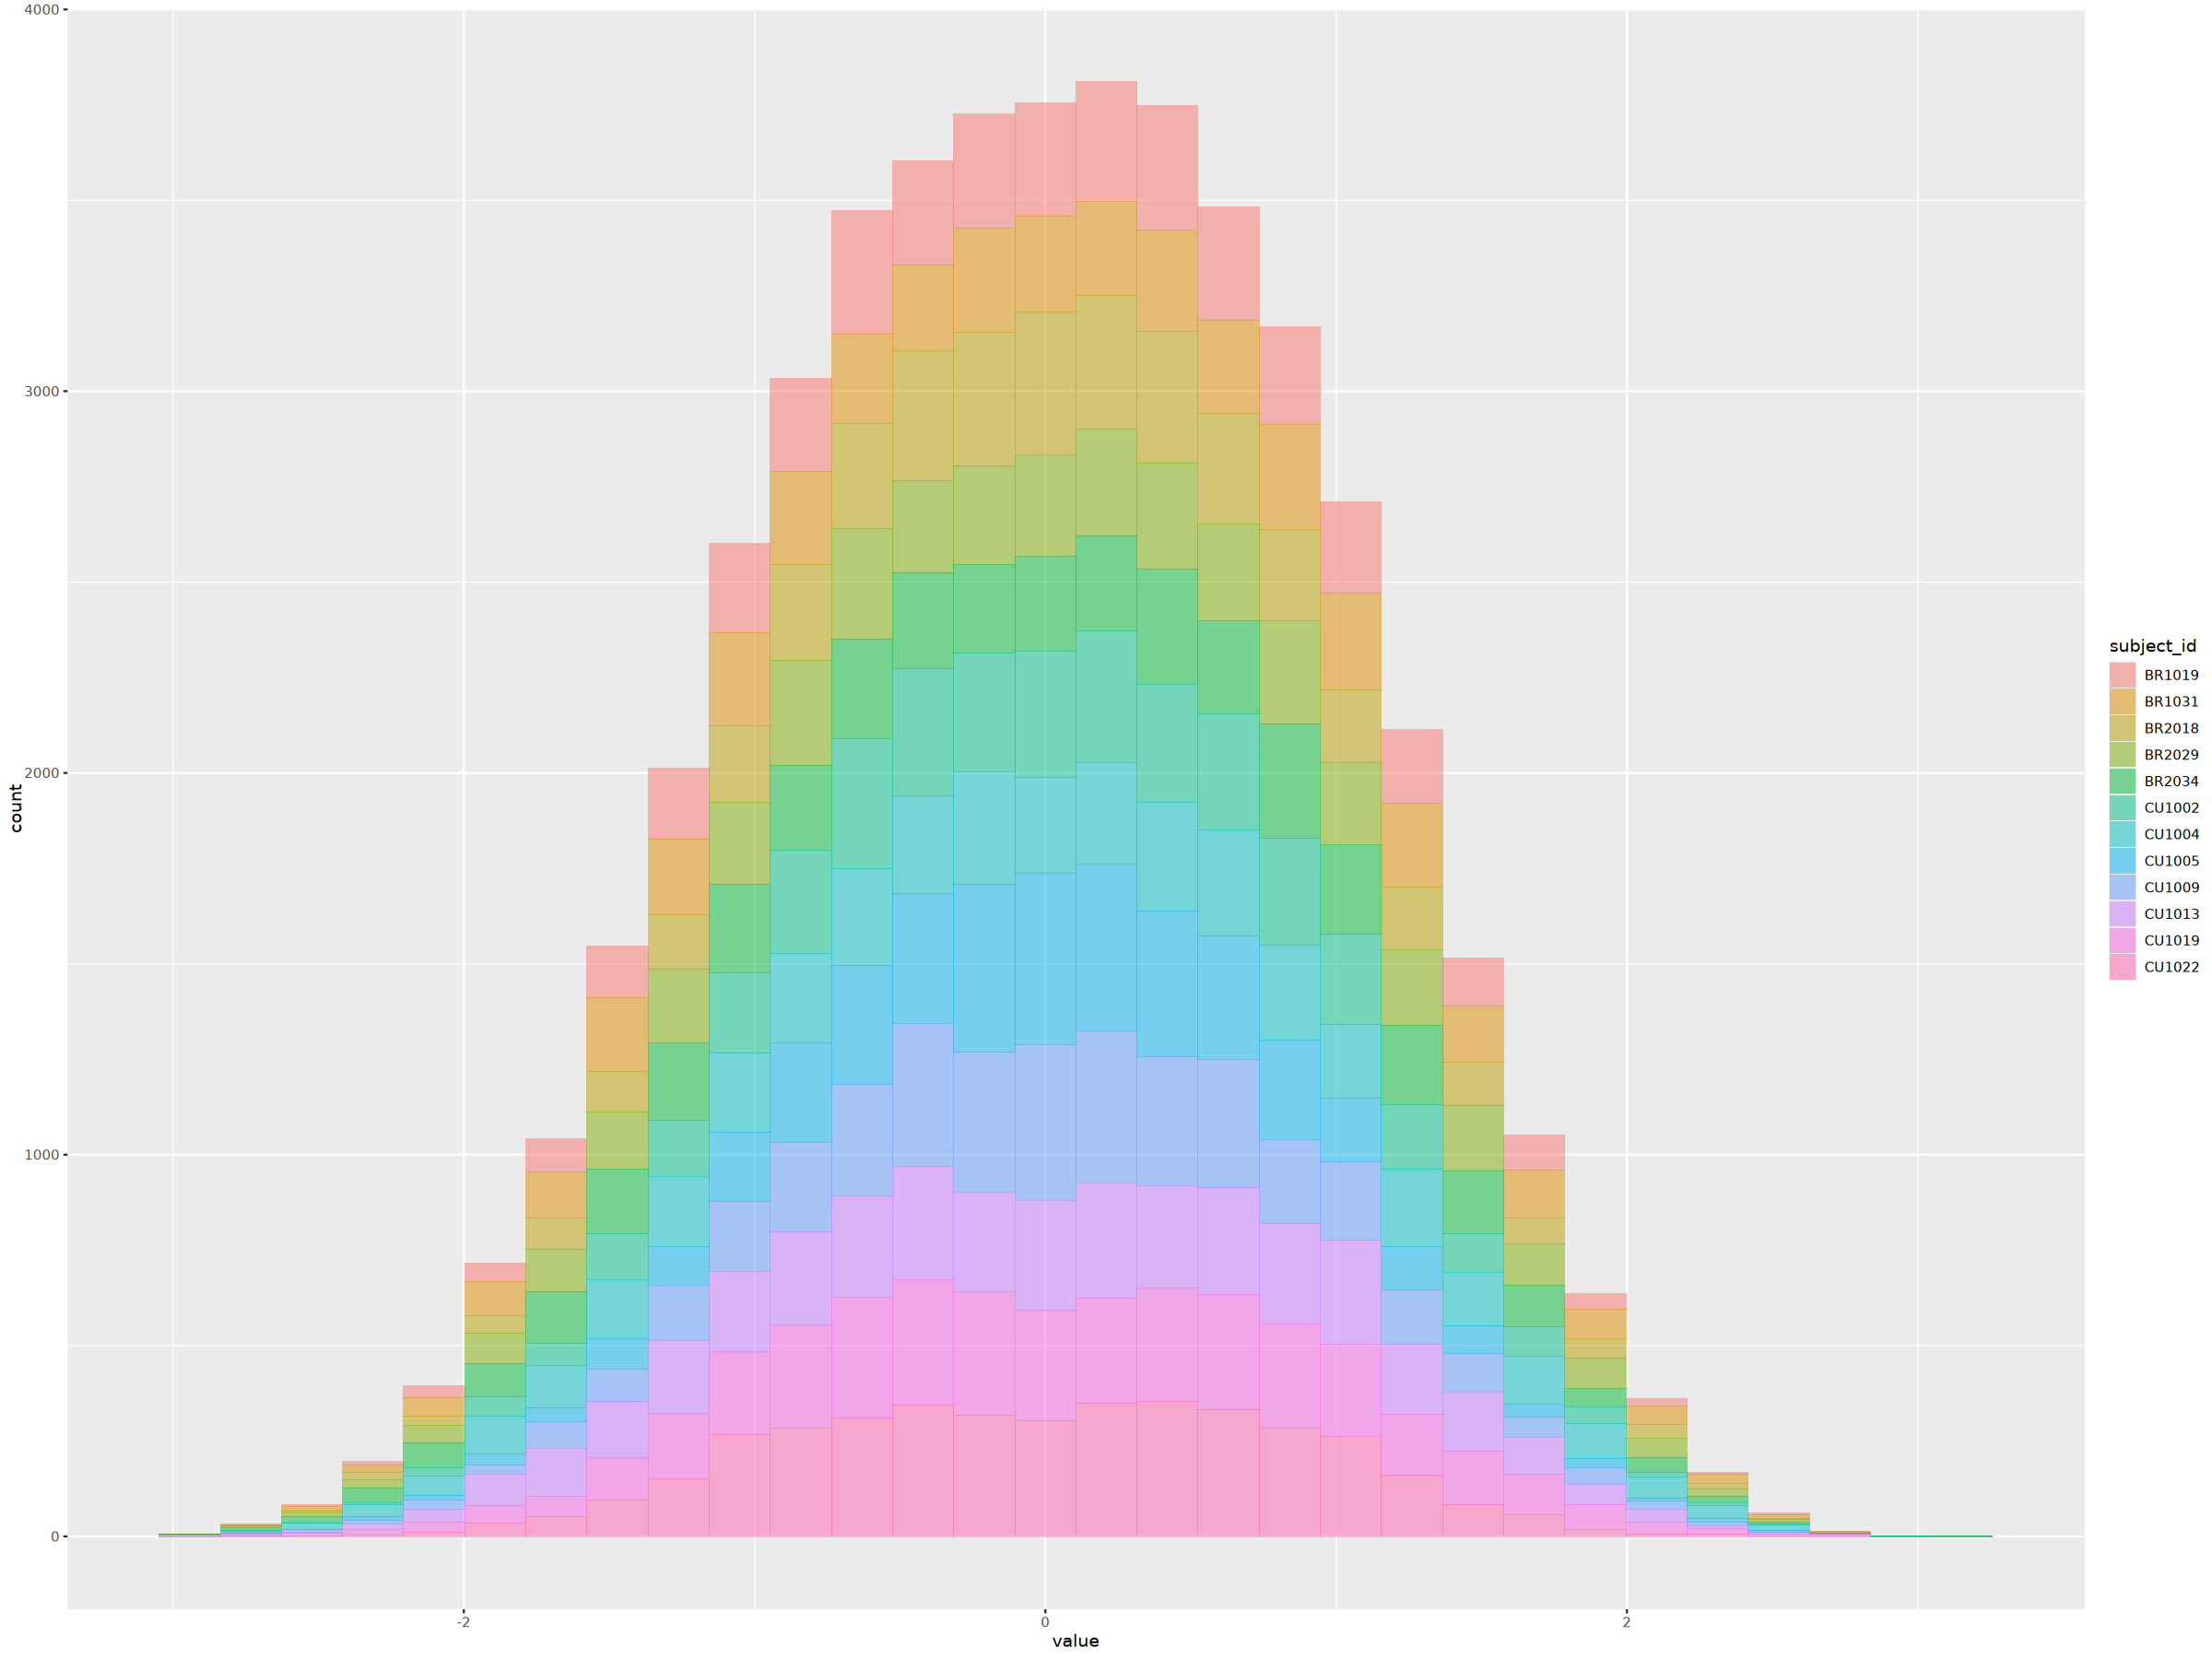

In [10]:
# check if the data is scaled
norm_rna_counts_long %>% ggplot(aes(x = value, fill = subject_id)) +
  geom_histogram(alpha = 0.5)

In [12]:
# load adt psudobulk
# adt data is summarized at the sample level and similar to rna data, it is scaled per MOFA requirement
cd4na_adt_psudo <- readRDS(file.path(data_path, "PreRA_teaseq_cd4na_t_adt_subject_PseudoBulk.rds"))
cd4na_adt_psudo

class: SingleCellExperiment 
dim: 157 12 
metadata(0):
assays(2): counts norm_counts
rownames(157): CD86 CD274 ... CD80 TCR-Va24.Ja18
rowData names(0):
colnames: NULL
colData names(98): nCount_ADT nFeature_ADT ...
  colData.cd4na_tea_adt....c..subject_id... ncells
reducedDimNames(10): PCA REF.SPCA ... ADT_UMAP APCA
mainExpName: ADT
altExpNames(0):

In [13]:
# extract the rna data for all cell type
norm_adt_counts <- assay(cd4na_adt_psudo, "norm_counts")
colnames(norm_adt_counts) <- cd4na_adt_psudo$subject_id
norm_adt_counts_long <- norm_adt_counts %>%
  as_tibble(rownames = "gene") %>%
  pivot_longer(cols = -gene, names_to = "subject_id", values_to = "value") %>%
  mutate(view = "adt", feature = paste("adt", gene, sep = "_")) %>%
  group_by(feature) %>%
  mutate(value = scale(value)) %>%
  ungroup()
norm_adt_counts_long %>% head()

gene,subject_id,value,view,feature
<chr>,<chr>,"<dbl[,1]>",<chr>,<chr>
CD86,BR1019,0.4274904,adt,adt_CD86
CD86,BR1031,-0.9263961,adt,adt_CD86
CD86,BR2018,-0.1135745,adt,adt_CD86
CD86,BR2029,-0.9391116,adt,adt_CD86
CD86,BR2034,2.2237279,adt,adt_CD86
CD86,CU1002,0.2051270,adt,adt_CD86


In [21]:
# load chromvar z scores
l2_chromvar <- readRDS("/home/workspace/private/teaseq-analysis-v2-ide/preRA_teaseq/output_results/atac/preRA_teaseq_MOCHA_l2_celltype_chromavar.rds")
cd4na_dev <- l2_chromvar[["cd4_naive"]]$Z_Score
cd4na_dev

class: SummarizedExperiment 
dim: 870 12 
metadata(2): SummarizedData History
assays(1): cd4_naive
rownames(870): TFAP2B TFAP2D ... TBX18 TBX22
rowData names(0):
colnames(12): EXP-00243-P1_PB00060-02 EXP-00243-P1_PB00065-05 ...
  EXP-00243-P1_PB00561-03 EXP-00243-P1_PB00569-04
colData names(8): Sample pool_id ... Birth.Year Sex

In [22]:
# remove one motif with empty values
cd4na_dev <- cd4na_dev[rownames(cd4na_dev) != "ENSG00000250542", ]
colnames(cd4na_dev) <- colData(cd4na_dev)$subject_id
cd4na_dev

class: SummarizedExperiment 
dim: 869 12 
metadata(2): SummarizedData History
assays(1): cd4_naive
rownames(869): TFAP2B TFAP2D ... TBX18 TBX22
rowData names(0):
colnames(12): CU1005 CU1013 ... BR2029 BR2018
colData names(8): Sample pool_id ... Birth.Year Sex

In [23]:
# extract the z score
chromvar_tf <- assay(cd4na_dev, "cd4_naive") %>%
  as_tibble(rownames = "tf") %>%
  pivot_longer(cols = -tf, names_to = "subject_id", values_to = "value") %>%
  mutate(view = "tf", feature = paste("tf", tf, sep = "_"))
chromvar_tf %>% head()

tf,subject_id,value,view,feature
<chr>,<chr>,<dbl>,<chr>,<chr>
TFAP2B,CU1005,1.0622665,tf,tf_TFAP2B
TFAP2B,CU1013,-0.0140062,tf,tf_TFAP2B
TFAP2B,CU1019,-0.4317825,tf,tf_TFAP2B
TFAP2B,CU1022,0.4902763,tf,tf_TFAP2B
TFAP2B,CU1002,0.7703097,tf,tf_TFAP2B
TFAP2B,CU1004,-0.5847513,tf,tf_TFAP2B


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


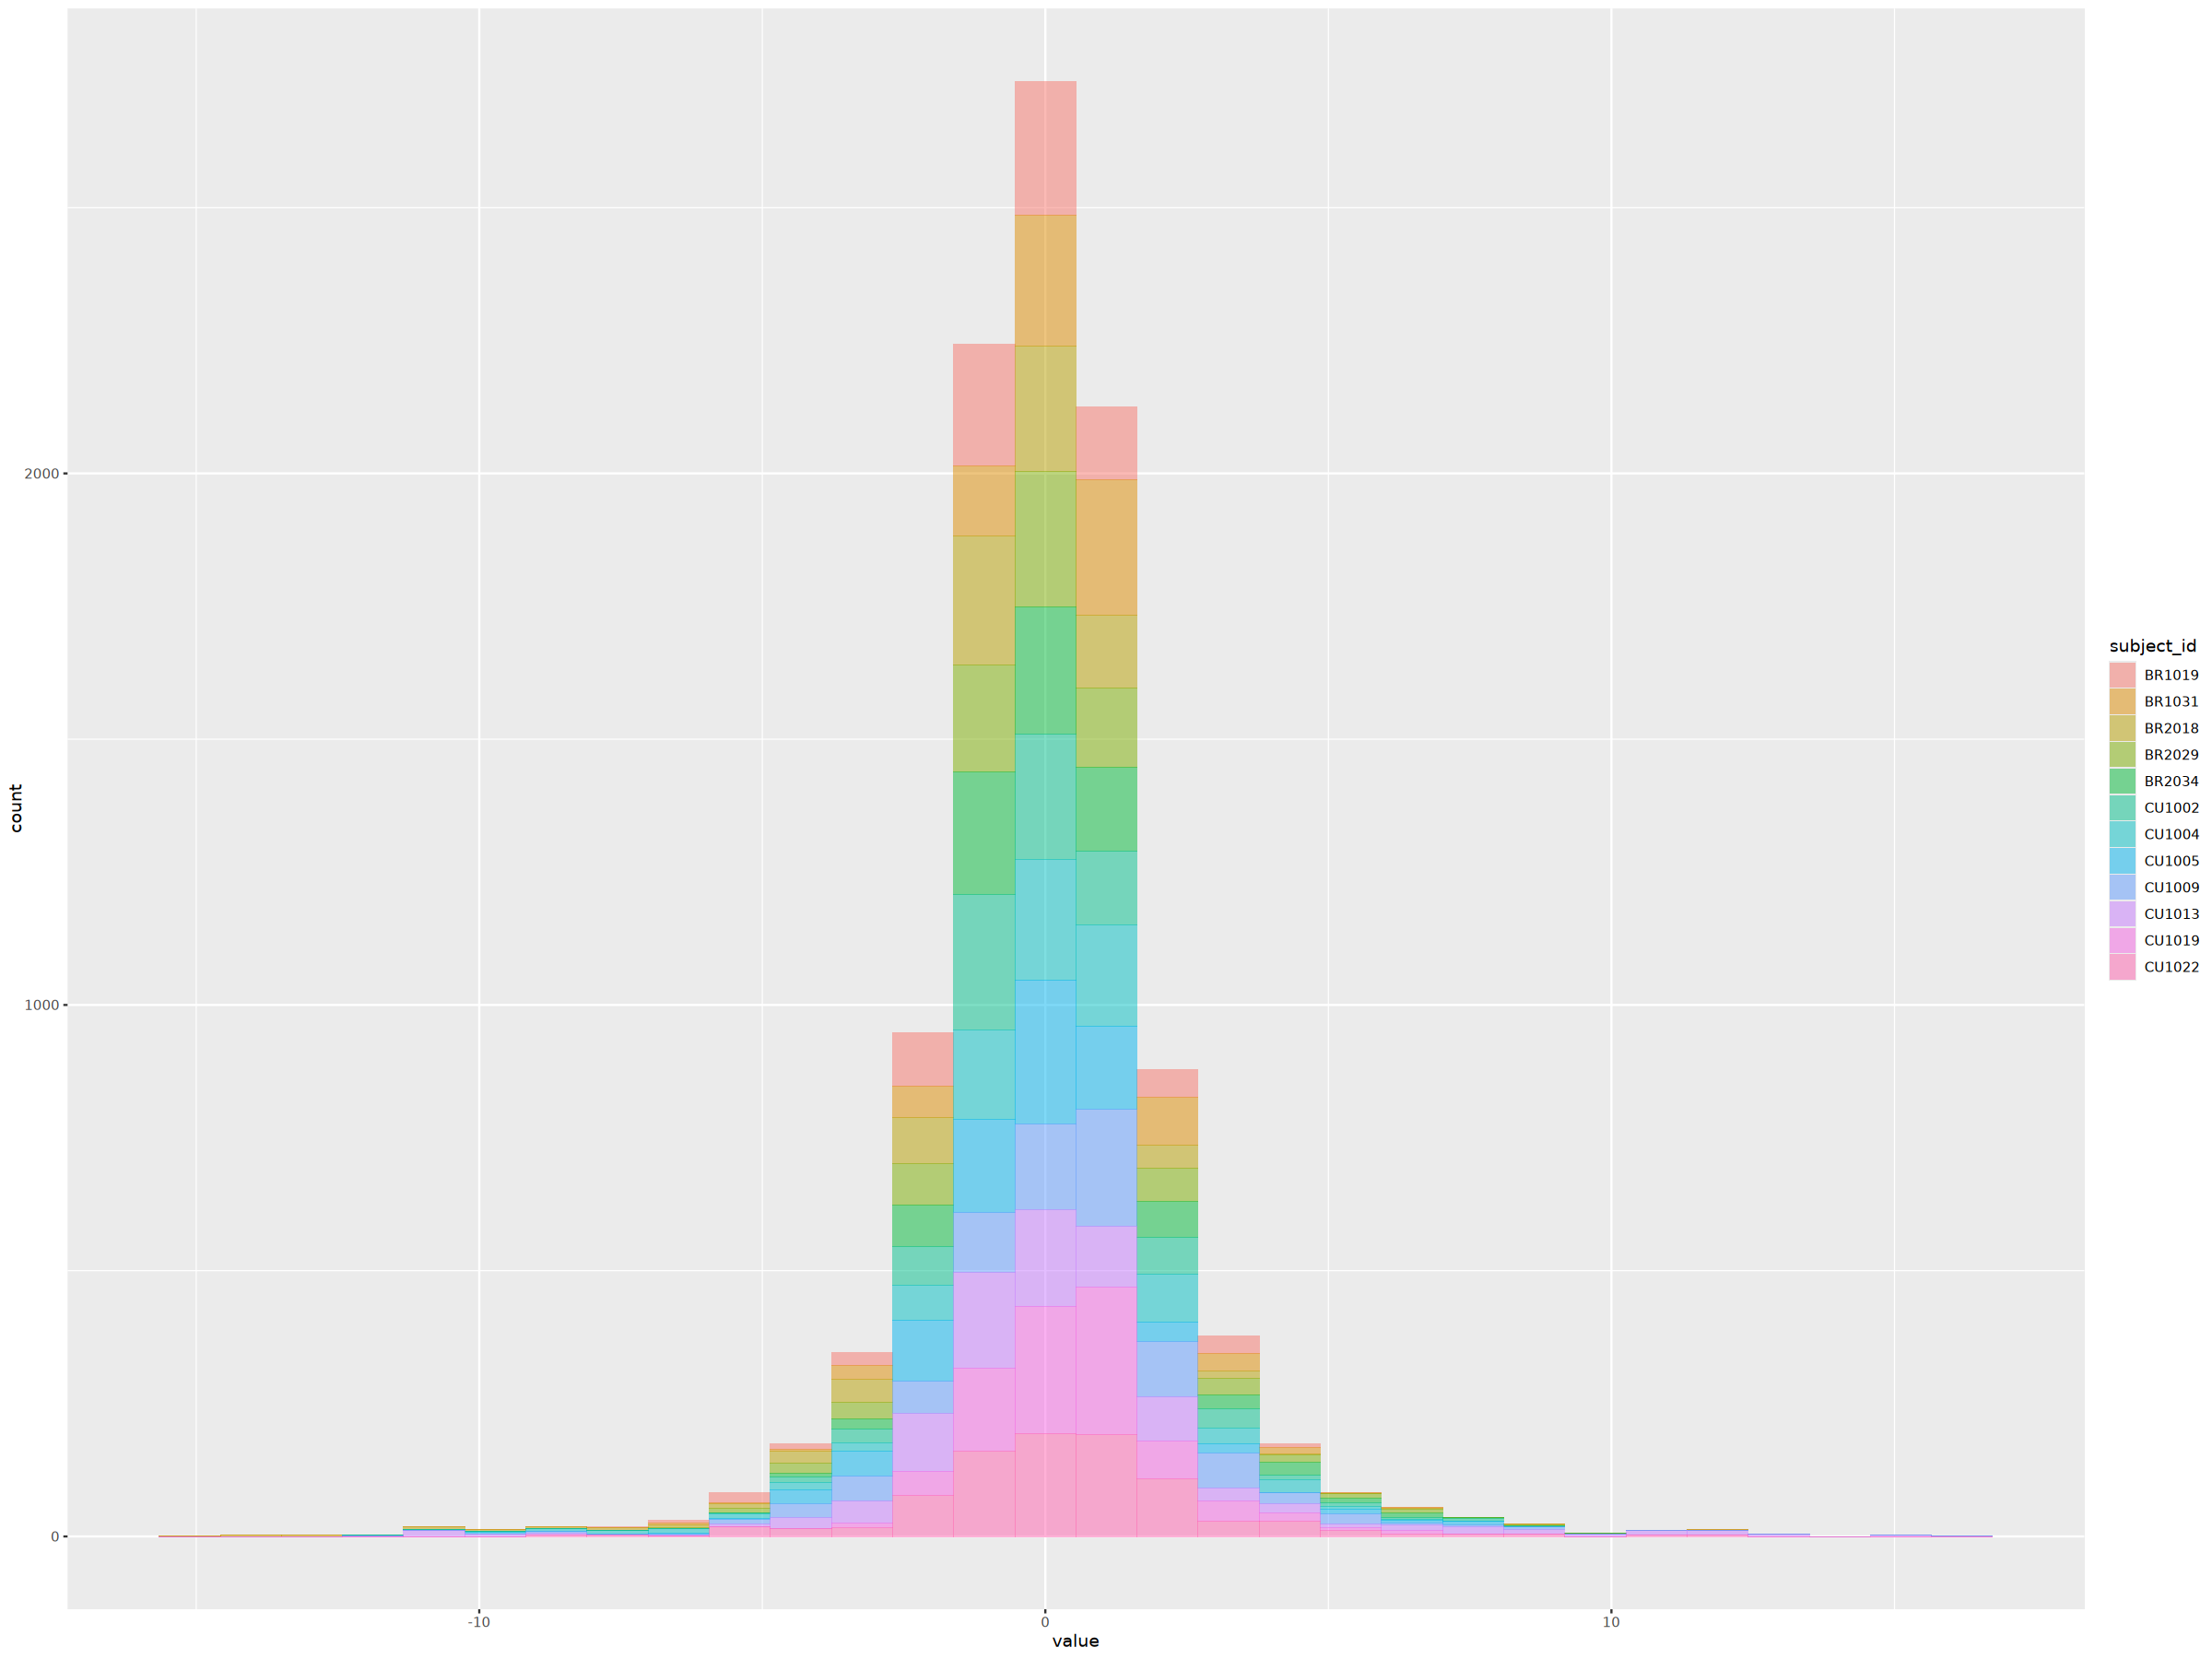

In [24]:
chromvar_tf %>% ggplot(aes(x = value, fill = subject_id)) +
  geom_histogram(alpha = 0.5)

### get OLINK data


In [30]:
hise::cacheFiles(list("5310fd9a-eddf-4fe1-b5b3-1813de5bb66f"))

[1] "downloading fileID 5310fd9a-eddf-4fe1-b5b3-1813de5bb66f"


[1] "/home/workspace/input/569004694/UCSDCU_Y4/5310fd9a-eddf-4fe1-b5b3-1813de5bb66f/2023-11-23_Olink_allCohorts_withMeta.csv"

In [38]:
# load the data that processed by Mark contains all olink data
olink_processed <- fread(
  "/home/workspace/input/569004694/UCSDCU_Y4/5310fd9a-eddf-4fe1-b5b3-1813de5bb66f/2023-11-23_Olink_allCohorts_withMeta.csv"
)

In [39]:
# filter the olink data to all 13 samples in teaseq
olink_fl <- olink_processed %>%
  filter(sample.sampleKitGuid %in% meta_data$sample.sampleKitGuid) %>%
  dplyr::select(SampleID:subject.subjectGuid) %>%
  distinct(Assay, sample.sampleKitGuid, .keep_all = TRUE)

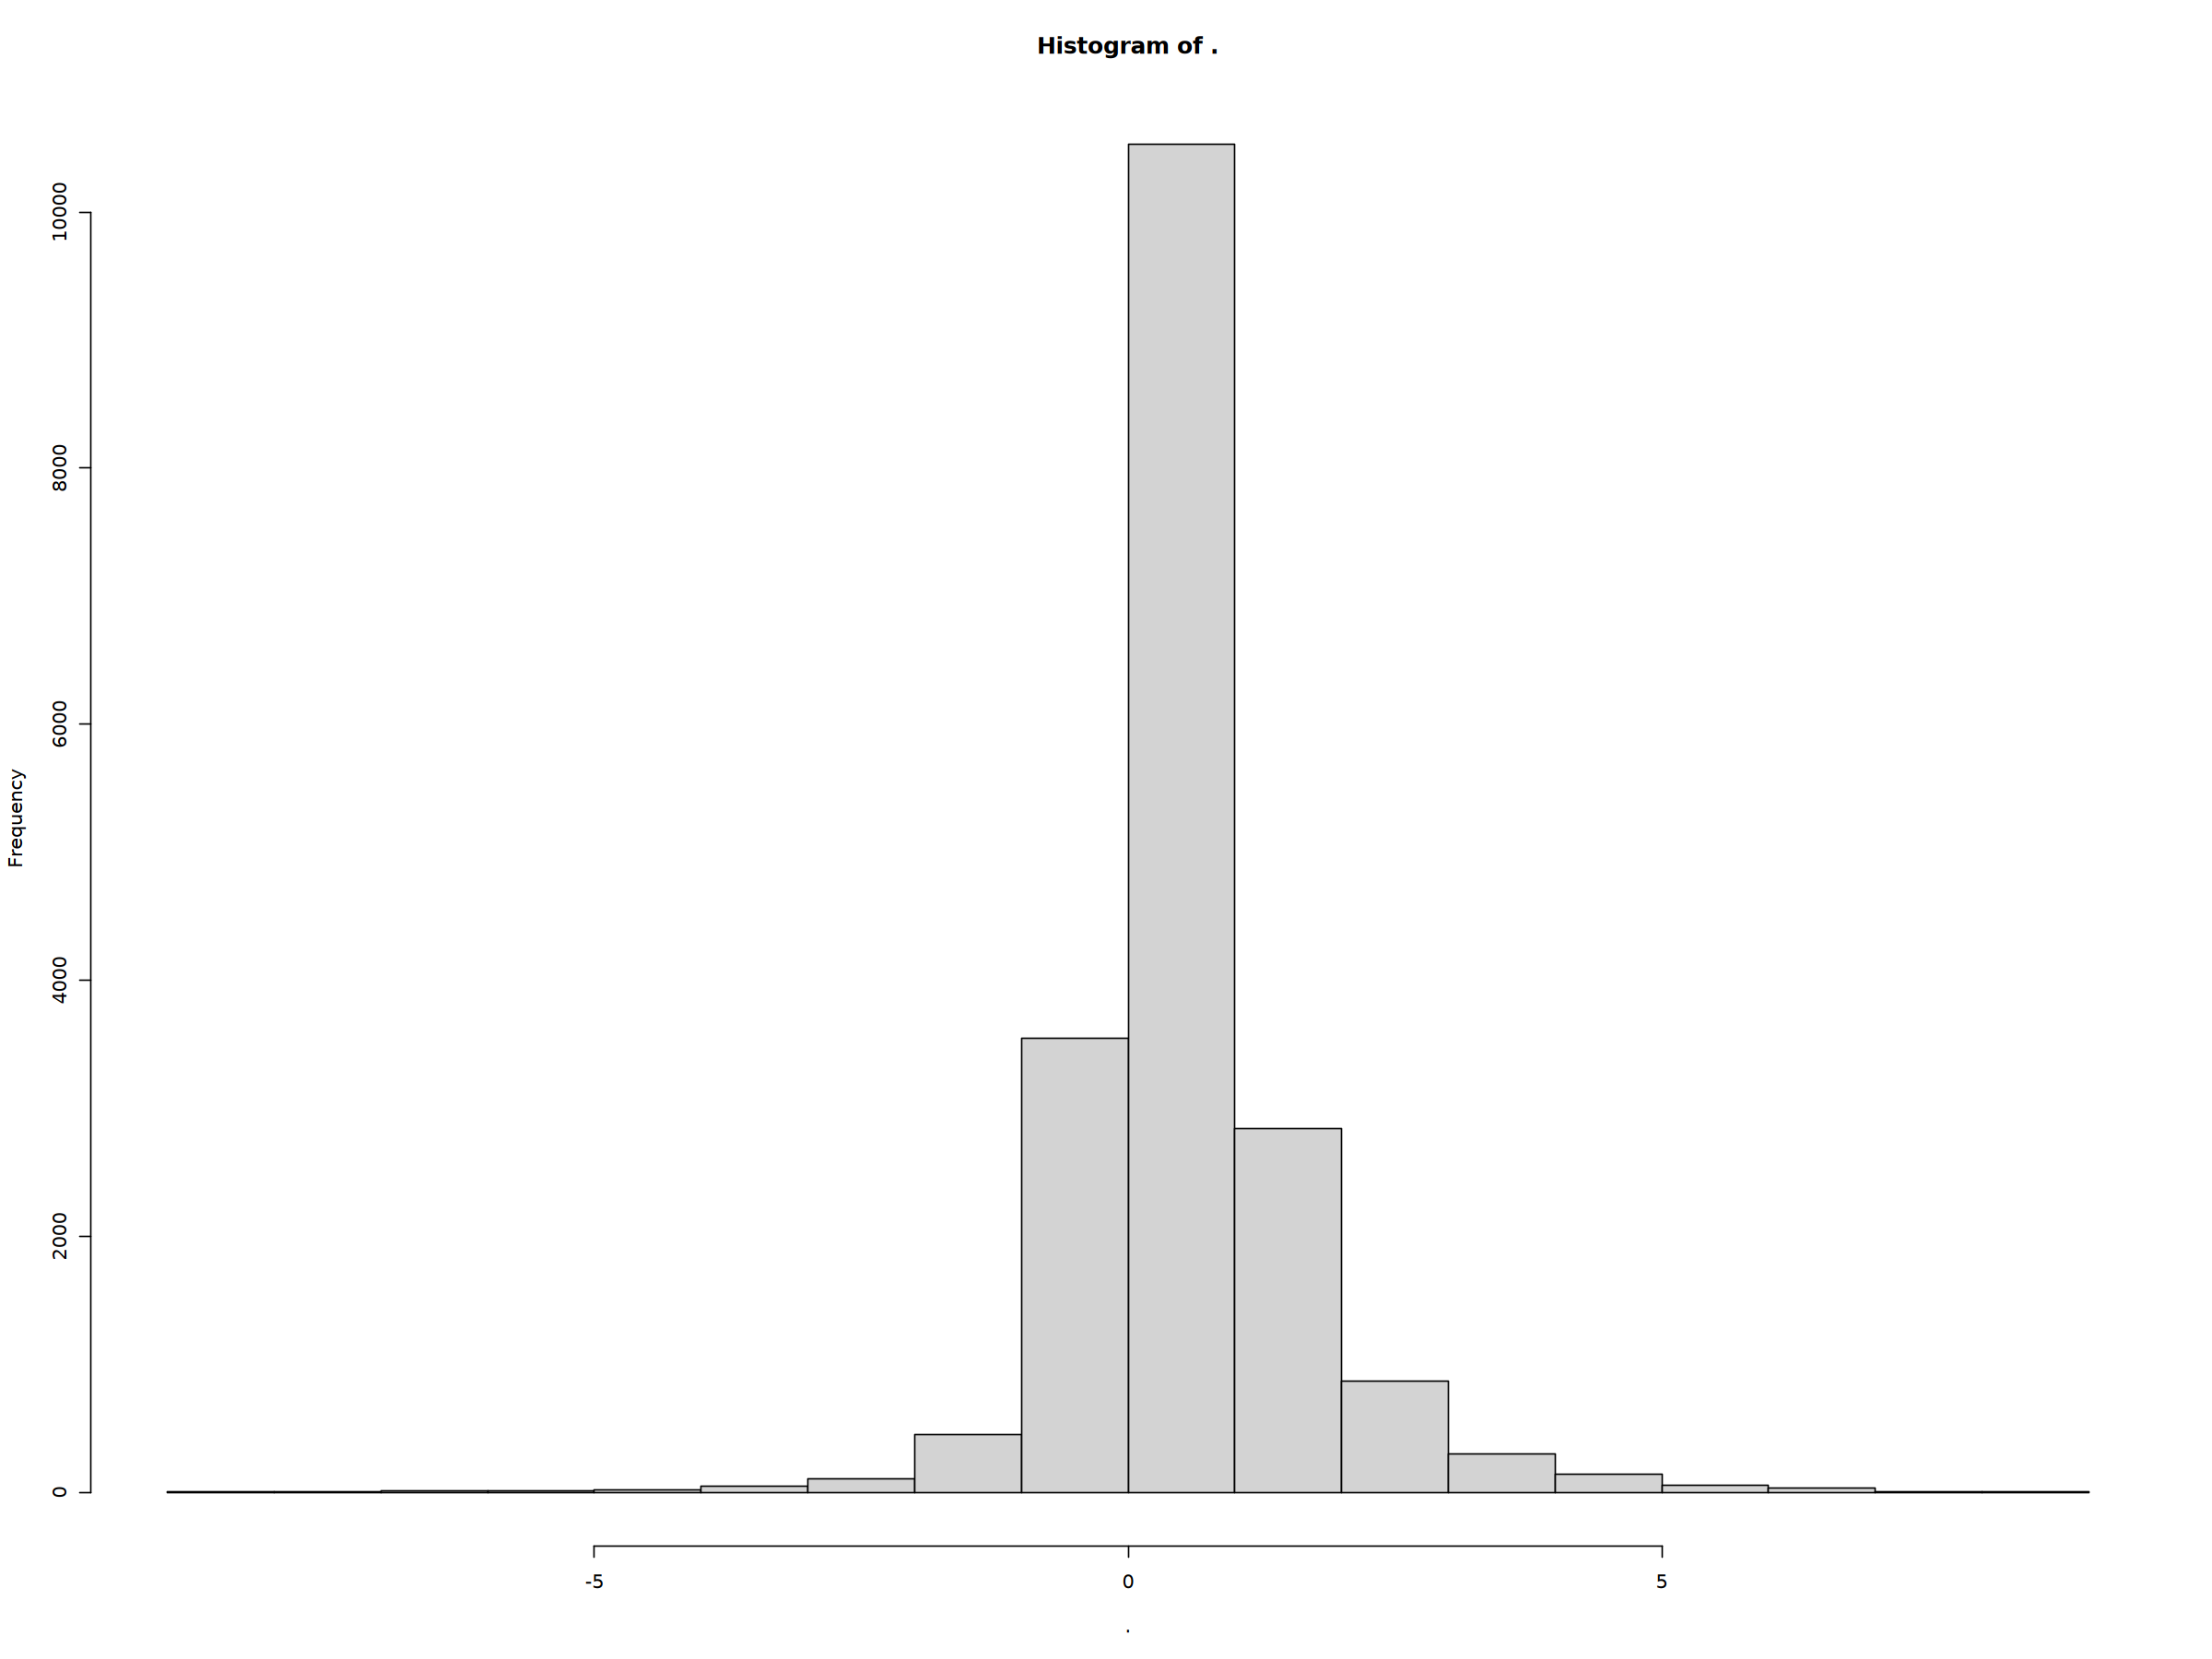

In [40]:
olink_fl$NPX_Final %>% hist()

In [41]:
# check feature number in OLINK assay
olink_fl %>%
  distinct(Assay) %>%
  nrow()

[1] 1463

In [42]:
# make a feature table for olink data for moda
olink_mofa <- olink_fl %>%
  dplyr::select(Assay, sample.sampleKitGuid, NPX_Final, subject.subjectGuid) %>%
  dplyr::rename("feature" = "Assay", "value" = "NPX_Final", "subject_id" = "subject.subjectGuid") %>%
  mutate(view = "olink") %>%
  mutate(feature = paste(view, feature, sep = "_"))

# create MOFA object


In [43]:
# creat a lone data table of all modalities combine
mofa_dt <- rbindlist(list(
  norm_rna_counts_long %>% dplyr::select(c(subject_id, value, view, feature)),
  norm_adt_counts_long %>% dplyr::select(c(subject_id, value, view, feature)),
  olink_mofa %>% dplyr::select(c(subject_id, value, view, feature)),
  chromvar_tf %>% dplyr::select(c(subject_id, value, view, feature))
), use.names = TRUE) %>%
  dplyr::rename("sample" = "subject_id") %>%
  as_tibble()
mofa_dt %>% head()
# check how many features are in each view
mofa_dt %>%
  group_by(view) %>%
  distinct(feature) %>%
  tally()

sample,value,view,feature
<chr>,<dbl>,<chr>,<chr>
BR1019,0.1396079,rna,rna_CCNL2
BR1031,0.4630008,rna,rna_CCNL2
BR2018,0.2853191,rna,rna_CCNL2
BR2029,-2.1981312,rna,rna_CCNL2
BR2034,0.9791970,rna,rna_CCNL2
CU1002,-1.2806773,rna,rna_CCNL2


view,n
<chr>,<int>
adt,157
olink,1463
rna,4089
tf,869


In [44]:
# remove subject BR2024 from the analysis
# this con2 subject had a positive CCP result and was removed from the analysis
mofa_dt <- mofa_dt %>% filter(sample != "BR2024")

In [45]:
mofa_dt %>% head()

sample,value,view,feature
<chr>,<dbl>,<chr>,<chr>
BR1019,0.1396079,rna,rna_CCNL2
BR1031,0.4630008,rna,rna_CCNL2
BR2018,0.2853191,rna,rna_CCNL2
BR2029,-2.1981312,rna,rna_CCNL2
BR2034,0.9791970,rna,rna_CCNL2
CU1002,-1.2806773,rna,rna_CCNL2


In [48]:
# save MOFA data table
# mofa_dt %>% write_tsv(file.path(output_path, "mofa_preRA_cd4_rna_adt_olink_tf_pseudobulk_data_092023.tsv"))

In [47]:
# load the data table
mofa_dt <- read_tsv(file.path(output_path, "mofa_preRA_cd4_rna_adt_olink_tf_pseudobulk_data_092023.tsv"),
  show_col_types = FALSE
)

In [49]:
# create a MOFA object
MOFAobject <- create_mofa(mofa_dt)

Creating MOFA object from a data.frame...



Untrained MOFA model with the following characteristics: 
 Number of views: 4 
 Views names: adt olink rna tf 
 Number of features (per view): 157 1463 4089 869 
 Number of groups: 1 
 Groups names: single_group 
 Number of samples (per group): 12 
 


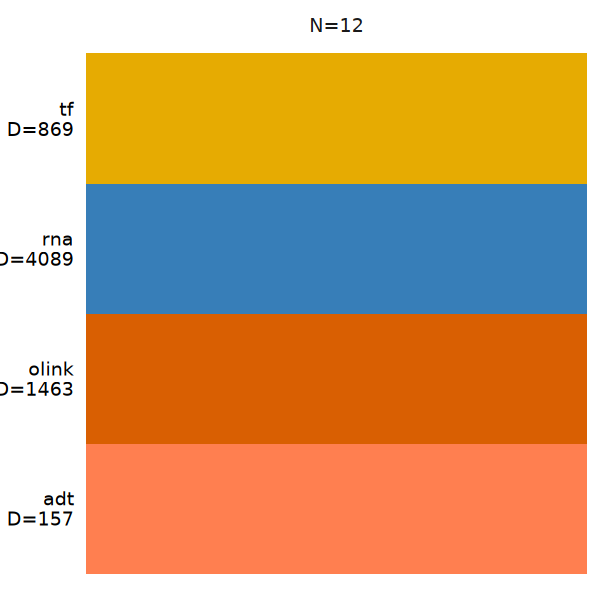

In [51]:
print(MOFAobject)
options(repr.plot.width = 5, repr.plot.height = 5)
plot_data_overview(MOFAobject)
ggsave(file.path(fig_path, paste0(proj_name, "_data_overview.png")),
  width = 6, height = 6
)

In [52]:
data_opts <- get_default_data_options(MOFAobject)
data_opts$scale_views <- TRUE

In [53]:
model_opts <- get_default_model_options(MOFAobject)
# set the number of factors to 6
model_opts$num_factors <- 6
head(model_opts)

$likelihoods
       adt      olink        rna         tf 
"gaussian" "gaussian" "gaussian" "gaussian" 

$num_factors
[1] 6

$spikeslab_factors
[1] FALSE

$spikeslab_weights
[1] FALSE

$ard_factors
[1] FALSE

$ard_weights
[1] TRUE

In [54]:
train_opts <- get_default_training_options(MOFAobject)
head(train_opts)

$maxiter
[1] 1000

$convergence_mode
[1] "fast"

$drop_factor_threshold
[1] -1

$verbose
[1] FALSE

$startELBO
[1] 1

$freqELBO
[1] 5

In [55]:
MOFAobject <- prepare_mofa(
  object = MOFAobject,
  data_options = data_opts,
  model_options = model_opts,
  training_options = train_opts
)

Checking data options...

Checking training options...

Checking model options...

Warning message in prepare_mofa(object = MOFAobject, data_options = data_opts, model_options = model_opts, :
“The total number of samples is very small for learning 6 factors.  
    Try to reduce the number of factors to obtain meaningful results. It should not exceed ~3.”


# train mofa model


In [ ]:
# train mofa model
outfile <- file.path(output_path, "mofa_preRA_cd4_rna_adt_olink_tf_pseudobulk_model_09202023.hdf5")
MOFAobject.trained <- run_mofa(MOFAobject, outfile, use_basilisk = TRUE)

In [117]:
sessionInfo()

R version 4.4.2 (2024-10-31)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/r_scrna/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
 [1] grid      stats4    parallel  stats     graphics  grDevices utils    
 [8] datasets  methods   base     

other attached packages:
 [1] ComplexHeatmap_2.22.0       hise_2.16.0                
 [3] SingleCellExperiment_1.28.0 SummarizedExperiment_1.36.0
 [5] Biobase_2.66.0              GenomicRanges_1.58.0       
 [7] GenomeInfoDb_1.42.0         IRanges_2.40.0             
 [9] S4Vectors_0.44.0            BiocGene